In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_PATH = "/content/drive/MyDrive/Coding/FCSO Image Identification"

INPUT_PATH = os.path.join(BASE_PATH, "Input")
TEST_PATH = os.path.join(BASE_PATH, "Test Set")

print("Input Folder Exists:", os.path.exists(INPUT_PATH))
print("Test Folder Exists:", os.path.exists(TEST_PATH))

print("\nInput Files:")
print(os.listdir(INPUT_PATH))

print("\nNumber of Test Images:")
print(len(os.listdir(TEST_PATH)))

Input Folder Exists: True
Test Folder Exists: True

Input Files:
['Input_Yee Jenn Jong.jpeg']

Number of Test Images:
15


In [4]:
!pip install -q insightface onnxruntime
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)

app.prepare(ctx_id=-1, det_size=(640, 640))

print("InsightFace model loaded successfully on CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 95.7 MB/s eta 0:00:00
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 95430.29KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
InsightFace 

In [5]:
!pip install -q opencv-python-headless

Probe Images: ['Input_Yee Jenn Jong.jpeg']

Using Probe Image:
/content/drive/MyDrive/Coding/FCSO Image Identification/Input/Input_Yee Jenn Jong.jpeg

Number of faces detected: 1


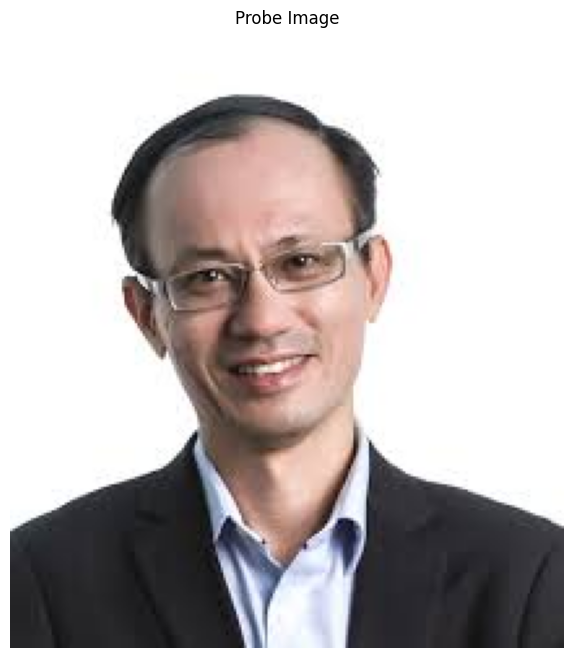


Face 1
Detection Confidence: 0.8814
Bounding Box: [ 53  38 136 155]
Embedding Shape: (512,)


In [6]:
import os
import cv2
import matplotlib.pyplot as plt

# Get probe image path
probe_images = os.listdir(INPUT_PATH)

print("Probe Images:", probe_images)

probe_image_path = os.path.join(INPUT_PATH, probe_images[0])

print("\nUsing Probe Image:")
print(probe_image_path)

# Read image
img = cv2.imread(probe_image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect faces
faces = app.get(img)

print("\nNumber of faces detected:", len(faces))

# Display image
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Probe Image")
plt.show()

# Print face details
for idx, face in enumerate(faces):

    print(f"\nFace {idx+1}")

    print("Detection Confidence:", round(face.det_score, 4))

    bbox = face.bbox.astype(int)
    print("Bounding Box:", bbox)

    embedding = face.embedding
    print("Embedding Shape:", embedding.shape)

Helper reusable functions for:

* loading images
* detecting the best face
* calculating blur and brightness
* extracting embedding
* returning quality details

In [7]:
import numpy as np
import pandas as pd

def calculate_blur_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_brightness(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray.mean()

def get_largest_face(faces):
    if len(faces) == 0:
        return None

    def face_area(face):
        x1, y1, x2, y2 = face.bbox
        return (x2 - x1) * (y2 - y1)

    return max(faces, key=face_area)

def extract_face_info(image_path, app):
    image = cv2.imread(image_path)

    if image is None:
        return {
            "image_path": image_path,
            "status": "FAIL",
            "notes": "Image could not be read",
            "embedding": None
        }

    faces = app.get(image)

    blur_score = calculate_blur_score(image)
    brightness = calculate_brightness(image)

    if len(faces) == 0:
        return {
            "image_path": image_path,
            "status": "FAIL",
            "notes": "No face detected",
            "num_faces": 0,
            "det_score": None,
            "bbox": None,
            "blur_score": blur_score,
            "brightness": brightness,
            "embedding": None
        }

    selected_face = get_largest_face(faces)
    bbox = selected_face.bbox.astype(int)

    face_width = bbox[2] - bbox[0]
    face_height = bbox[3] - bbox[1]

    notes = []

    if len(faces) > 1:
        notes.append("Multiple faces detected; largest face used")

    if selected_face.det_score < 0.70:
        notes.append("Low face detection confidence")

    if face_width < 80 or face_height < 80:
        notes.append("Small face size")

    if blur_score < 50:
        notes.append("Image may be blurry")

    if brightness < 40:
        notes.append("Image may be too dark")

    if brightness > 220:
        notes.append("Image may be too bright")

    status = "PASS" if len(notes) == 0 else "WARNING"

    return {
        "image_path": image_path,
        "status": status,
        "notes": "; ".join(notes) if notes else "Good quality image",
        "num_faces": len(faces),
        "det_score": float(selected_face.det_score),
        "bbox": bbox.tolist(),
        "face_width": int(face_width),
        "face_height": int(face_height),
        "blur_score": float(blur_score),
        "brightness": float(brightness),
        "embedding": selected_face.embedding
    }

def cosine_similarity(vec1, vec2):
    vec1 = vec1 / np.linalg.norm(vec1)
    vec2 = vec2 / np.linalg.norm(vec2)
    return float(np.dot(vec1, vec2))

print("Helper functions created successfully")

Helper functions created successfully


In [8]:
probe_result = extract_face_info(probe_image_path, app)

# Remove embedding temporarily for cleaner display
probe_display = probe_result.copy()
probe_display.pop("embedding")

print("Probe Image Analysis:\n")

for key, value in probe_display.items():
    print(f"{key}: {value}")

Probe Image Analysis:

image_path: /content/drive/MyDrive/Coding/FCSO Image Identification/Input/Input_Yee Jenn Jong.jpeg
status: PASS
notes: Good quality image
num_faces: 1
det_score: 0.8814139366149902
bbox: [53, 38, 136, 155]
face_width: 83
face_height: 117
blur_score: 1062.3317204045507
brightness: 179.61359719498427


In [9]:
# Supported image extensions
valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".bmp")

target_files = [
    f for f in os.listdir(TEST_PATH)
    if f.lower().endswith(valid_extensions)
]

print("Number of target images found:", len(target_files))

target_results = []

for file_name in target_files:
    image_path = os.path.join(TEST_PATH, file_name)
    result = extract_face_info(image_path, app)
    result["file_name"] = file_name
    target_results.append(result)

print("Target image processing completed")

Number of target images found: 15
Target image processing completed


In [10]:
# Create quality report without embedding column
quality_rows = []

for r in target_results:
    row = r.copy()
    row.pop("embedding", None)
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)

quality_df[[
    "file_name",
    "status",
    "notes",
    "num_faces",
    "det_score",
    "face_width",
    "face_height",
    "blur_score",
    "brightness"
]]

,file_name,status,notes,num_faces,det_score,face_width,face_height,blur_score,brightness
0,Target_1.1.jpeg,WARNING,Small face size,1,0.788408,48,63,1481.764914,101.329419
1,Target_1.2.jpeg,WARNING,Low face detection confidence,1,0.657245,94,143,461.243175,95.165025
2,Target_1.3.jpeg,WARNING,Multiple faces detected; largest face used; Sm...,4,0.856697,51,67,1921.668031,181.415654
3,Target_1.4.jpeg,WARNING,Small face size,1,0.816855,74,107,1300.358138,107.751035
4,Target_2.1.jpeg,PASS,Good quality image,1,0.835474,92,132,561.959595,54.140002
5,Target_3.1.jpeg,PASS,Good quality image,1,0.882884,89,114,834.002246,122.002475
6,Target_4.1.jpeg,PASS,Good quality image,1,0.882235,85,120,215.934197,205.147594
7,Target_5.1.jpeg,WARNING,Multiple faces detected; largest face used; Sm...,4,0.835355,47,59,2299.552722,122.824044
8,Target_6.1.jpeg,WARNING,Multiple faces detected; largest face used; Sm...,15,0.851407,17,22,3834.162400,97.315038
9,Target_7.1.jpeg,WARNING,Multiple faces detected; largest face used,3,0.829994,83,107,3547.804901,118.927330


In [11]:
similarity_results = []

probe_embedding = probe_result["embedding"]

for r in target_results:
    row = r.copy()
    row.pop("embedding", None)

    if r["embedding"] is not None:
        similarity = cosine_similarity(probe_embedding, r["embedding"])
        row["similarity_score"] = similarity
    else:
        row["similarity_score"] = None

    similarity_results.append(row)

similarity_df = pd.DataFrame(similarity_results)

ranked_df = similarity_df.sort_values(
    by="similarity_score",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

ranked_df["rank"] = ranked_df.index + 1

ranked_df[[
    "rank",
    "file_name",
    "similarity_score",
    "status",
    "notes",
    "num_faces",
    "det_score",
    "face_width",
    "face_height"
]]

,rank,file_name,similarity_score,status,notes,num_faces,det_score,face_width,face_height
0,1,Target_1.2.jpeg,0.750281,WARNING,Low face detection confidence,1,0.657245,94,143
1,2,Target_1.4.jpeg,0.655330,WARNING,Small face size,1,0.816855,74,107
2,3,Target_1.1.jpeg,0.630721,WARNING,Small face size,1,0.788408,48,63
3,4,Target_5.1.jpeg,0.034529,WARNING,Multiple faces detected; largest face used; Sm...,4,0.835355,47,59
4,5,Target_6.1.jpeg,0.033452,WARNING,Multiple faces detected; largest face used; Sm...,15,0.851407,17,22
5,6,Target_11.1.jpeg,0.022775,WARNING,Multiple faces detected; largest face used; Sm...,2,0.886011,76,112
6,7,Target_8.1.jpeg,0.018377,WARNING,Multiple faces detected; largest face used; Sm...,10,0.773305,50,63
7,8,Target_13.1.jpeg,0.010279,WARNING,Small face size,1,0.744596,66,84
8,9,Target_1.3.jpeg,0.006101,WARNING,Multiple faces detected; largest face used; Sm...,4,0.856697,51,67
9,10,Target_12.1.jpeg,-0.002497,WARNING,Small face size,1,0.819902,77,103


In [12]:
def similarity_label(score):

    if score is None:
        return "No Comparison"

    if score >= 0.70:
        return "Very High Similarity"

    elif score >= 0.50:
        return "Possible Similarity"

    elif score >= 0.30:
        return "Weak Similarity"

    else:
        return "Low Similarity"

ranked_df["similarity_label"] = ranked_df["similarity_score"].apply(similarity_label)

ranked_df[[
    "rank",
    "file_name",
    "similarity_score",
    "similarity_label",
    "status",
    "notes"
]]

,rank,file_name,similarity_score,similarity_label,status,notes
0,1,Target_1.2.jpeg,0.750281,Very High Similarity,WARNING,Low face detection confidence
1,2,Target_1.4.jpeg,0.655330,Possible Similarity,WARNING,Small face size
2,3,Target_1.1.jpeg,0.630721,Possible Similarity,WARNING,Small face size
3,4,Target_5.1.jpeg,0.034529,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...
4,5,Target_6.1.jpeg,0.033452,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...
5,6,Target_11.1.jpeg,0.022775,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...
6,7,Target_8.1.jpeg,0.018377,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...
7,8,Target_13.1.jpeg,0.010279,Low Similarity,WARNING,Small face size
8,9,Target_1.3.jpeg,0.006101,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...
9,10,Target_12.1.jpeg,-0.002497,Low Similarity,WARNING,Small face size


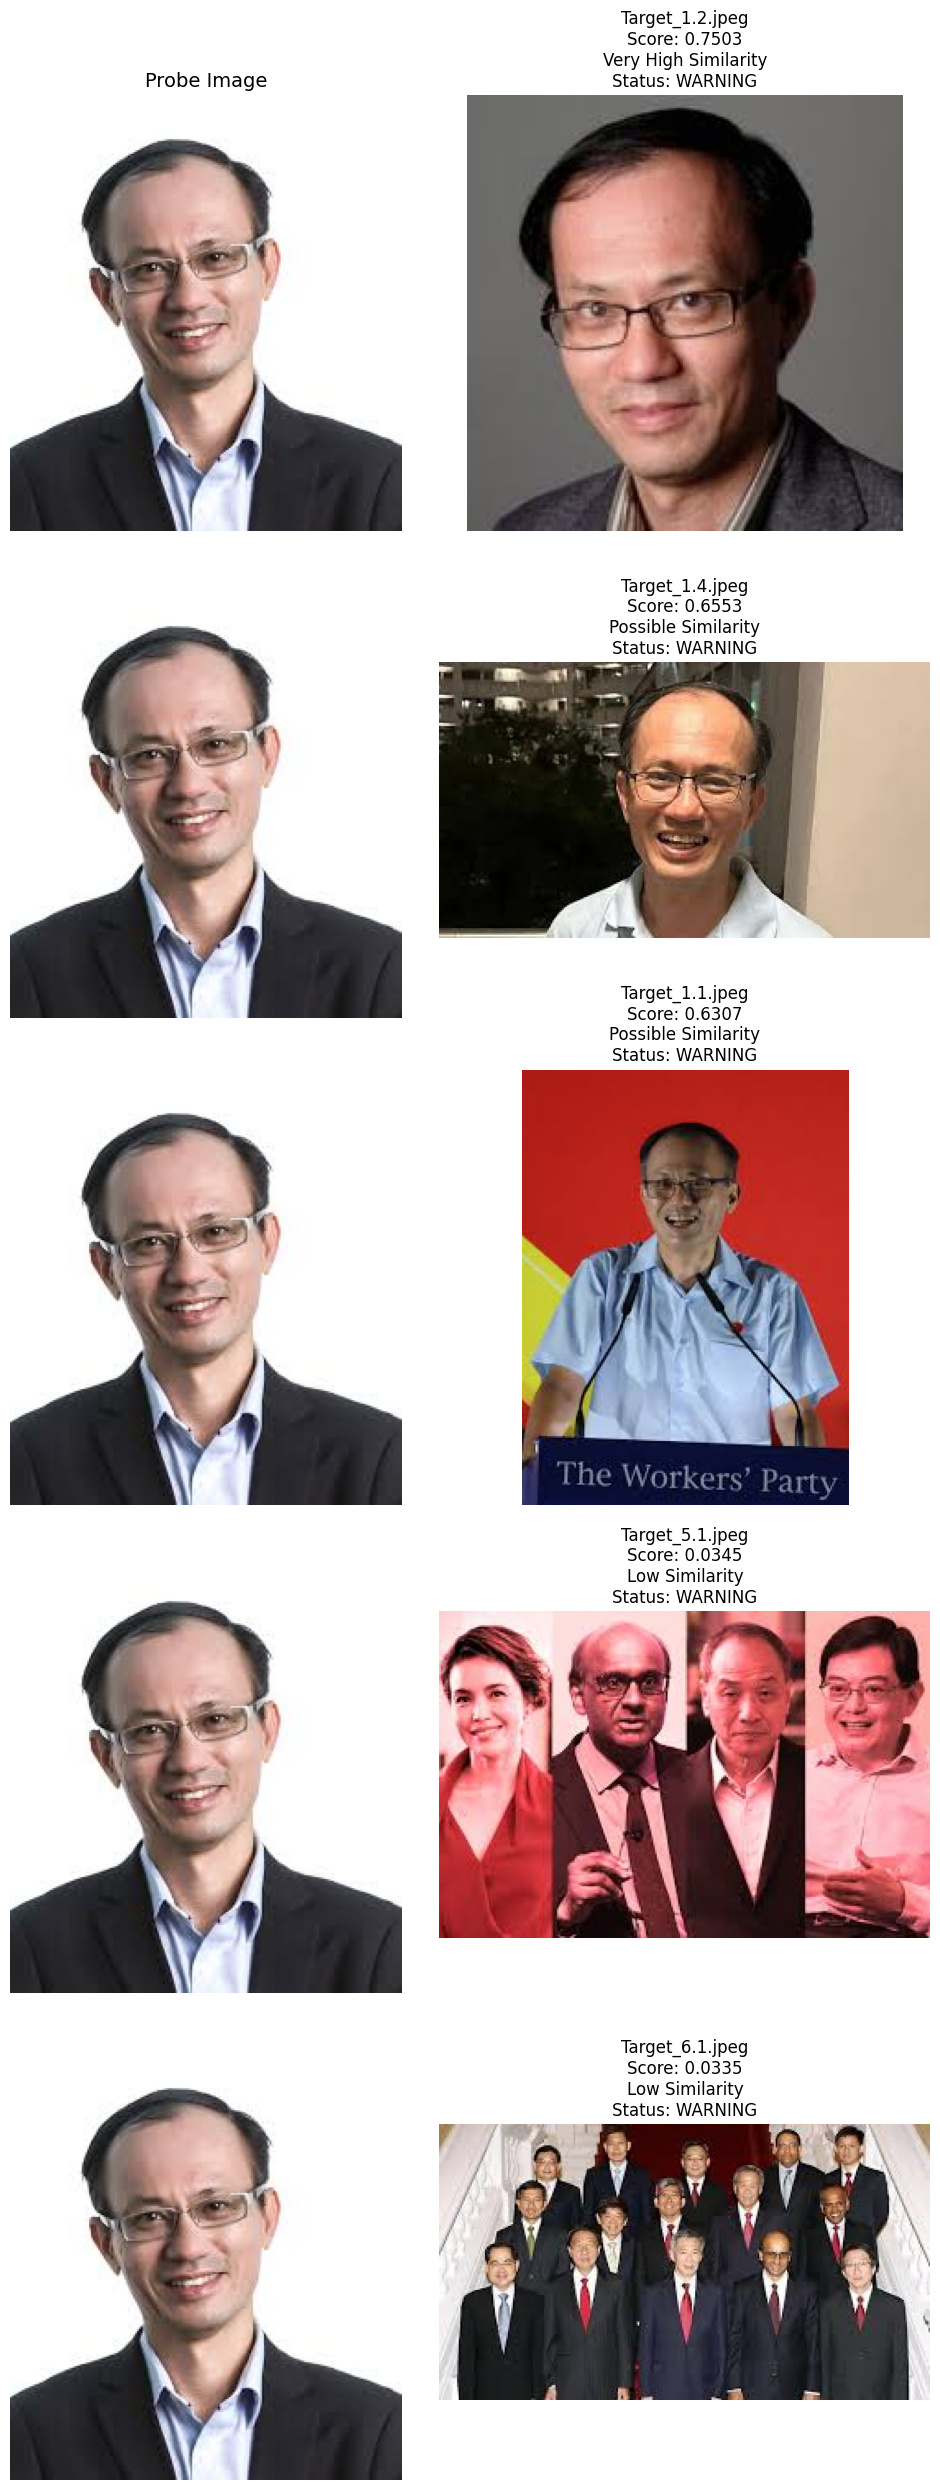

In [13]:
TOP_K = 5

top_matches = ranked_df.head(TOP_K)

probe_img_bgr = cv2.imread(probe_image_path)
probe_img_rgb = cv2.cvtColor(probe_img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(TOP_K, 2, figsize=(10, 5 * TOP_K))

for idx, (_, row) in enumerate(top_matches.iterrows()):

    # Left side → probe image
    axes[idx, 0].imshow(probe_img_rgb)
    axes[idx, 0].axis("off")

    if idx == 0:
        axes[idx, 0].set_title("Probe Image", fontsize=14)

    # Right side → target image
    target_path = os.path.join(TEST_PATH, row["file_name"])

    target_bgr = cv2.imread(target_path)
    target_rgb = cv2.cvtColor(target_bgr, cv2.COLOR_BGR2RGB)

    axes[idx, 1].imshow(target_rgb)
    axes[idx, 1].axis("off")

    title = (
        f'{row["file_name"]}\n'
        f'Score: {row["similarity_score"]:.4f}\n'
        f'{row["similarity_label"]}\n'
        f'Status: {row["status"]}'
    )

    axes[idx, 1].set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

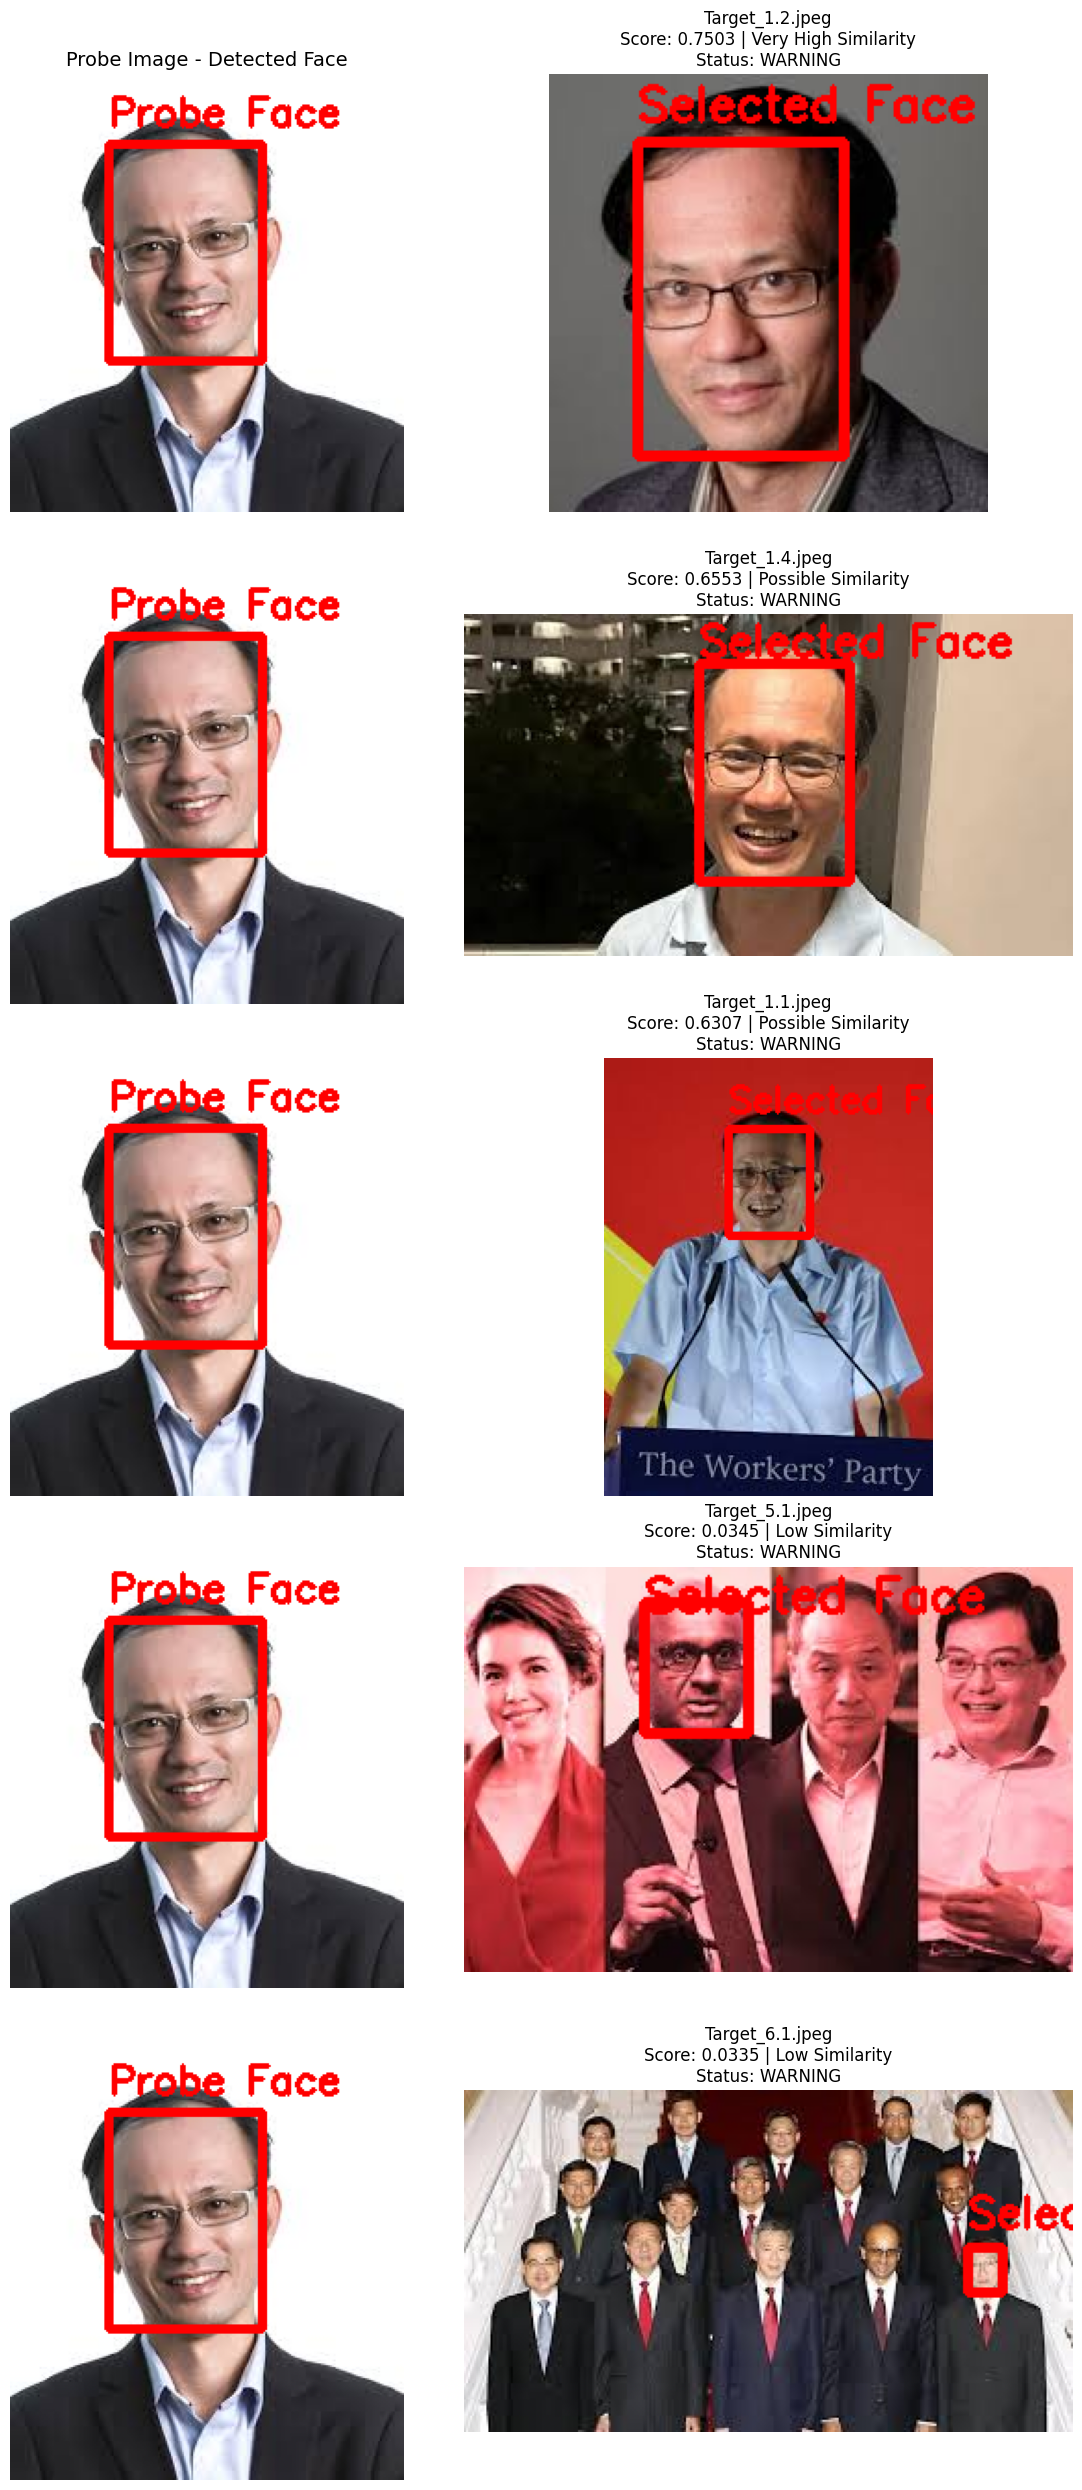

In [14]:
def draw_bbox(image_path, bbox, label=None):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if bbox is not None:
        x1, y1, x2, y2 = [int(v) for v in bbox]
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)

        if label:
            cv2.putText(
                image_rgb,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2
            )

    return image_rgb


TOP_K = 5
top_matches = ranked_df.head(TOP_K)

fig, axes = plt.subplots(TOP_K, 2, figsize=(12, 5 * TOP_K))

probe_bbox = probe_result["bbox"]
probe_box_img = draw_bbox(probe_image_path, probe_bbox, "Probe Face")

for idx, (_, row) in enumerate(top_matches.iterrows()):

    axes[idx, 0].imshow(probe_box_img)
    axes[idx, 0].axis("off")

    if idx == 0:
        axes[idx, 0].set_title("Probe Image - Detected Face", fontsize=14)

    target_path = os.path.join(TEST_PATH, row["file_name"])
    target_box_img = draw_bbox(target_path, row["bbox"], "Selected Face")

    axes[idx, 1].imshow(target_box_img)
    axes[idx, 1].axis("off")

    axes[idx, 1].set_title(
        f'{row["file_name"]}\n'
        f'Score: {row["similarity_score"]:.4f} | {row["similarity_label"]}\n'
        f'Status: {row["status"]}',
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [15]:
export_df = ranked_df[[
    "rank",
    "file_name",
    "similarity_score",
    "similarity_label",
    "status",
    "notes",
    "num_faces",
    "det_score",
    "face_width",
    "face_height",
    "blur_score",
    "brightness"
]].copy()

# Round numeric columns
numeric_cols = [
    "similarity_score",
    "det_score",
    "blur_score",
    "brightness"
]

for col in numeric_cols:
    export_df[col] = export_df[col].round(4)

# Save CSV
output_csv_path = os.path.join(BASE_PATH, "ranked_similarity_results.csv")

export_df.to_csv(output_csv_path, index=False)

print("CSV report saved at:")
print(output_csv_path)

export_df.head(10)

CSV report saved at:
/content/drive/MyDrive/Coding/FCSO Image Identification/ranked_similarity_results.csv


,rank,file_name,similarity_score,similarity_label,status,notes,num_faces,det_score,face_width,face_height,blur_score,brightness
0,1,Target_1.2.jpeg,0.7503,Very High Similarity,WARNING,Low face detection confidence,1,0.6572,94,143,461.2432,95.1650
1,2,Target_1.4.jpeg,0.6553,Possible Similarity,WARNING,Small face size,1,0.8169,74,107,1300.3581,107.7510
2,3,Target_1.1.jpeg,0.6307,Possible Similarity,WARNING,Small face size,1,0.7884,48,63,1481.7649,101.3294
3,4,Target_5.1.jpeg,0.0345,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...,4,0.8354,47,59,2299.5527,122.8240
4,5,Target_6.1.jpeg,0.0335,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...,15,0.8514,17,22,3834.1624,97.3150
5,6,Target_11.1.jpeg,0.0228,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...,2,0.8860,76,112,798.7138,98.5812
6,7,Target_8.1.jpeg,0.0184,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...,10,0.7733,50,63,2250.3330,132.4472
7,8,Target_13.1.jpeg,0.0103,Low Similarity,WARNING,Small face size,1,0.7446,66,84,1710.4021,160.1596
8,9,Target_1.3.jpeg,0.0061,Low Similarity,WARNING,Multiple faces detected; largest face used; Sm...,4,0.8567,51,67,1921.6680,181.4157
9,10,Target_12.1.jpeg,-0.0025,Low Similarity,WARNING,Small face size,1,0.8199,77,103,2370.4122,130.7197
